# AutoInt+ V3 학습 노트북
**피처 구성**: `user_id` | `movie_id` | `genre` | `narrative_keyword` (신규)

## 실행 순서
1. 라이브러리 & 경로 설정
2. 데이터 로드 & 전처리
3. field_dims 계산
4. 모델 생성 & 컴파일
5. 학습 루프 (EarlyStopping + 체크포인트)
6. 평가 & 가중치 저장
7. 추론 (predict_model)

---
## 0. 라이브러리 임포트

In [1]:
%pip install --quiet protobuf==6.31.1

import os
import sys
import time
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ─── V3 모델 임포트 ───────────────────────────────────────────────
# autointmlp_v3.py 가 같은 디렉토리에 있어야 합니다.
sys.path.append(os.path.dirname(os.path.abspath('__file__')))
from autointmlp_v3 import AutoIntMLPModel_V3, predict_model

# 재현성 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TF version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

Note: you may need to restart the kernel to use updated packages.


c:\Users\gusqh\anaconda3\envs\ds6_rcmm\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\gusqh\anaconda3\envs\ds6_rcmm\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\gusqh\anaconda3\envs\ds6_rcmm\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the genc

TF version: 2.20.0
GPU available: []


---
## 1. 경로 설정

In [12]:
# ── 경로 (환경에 맞게 수정) ───────────────────────────────────────
import os
DATA_DIR        = './' 
MODEL_DIR       = './model/'
os.makedirs(MODEL_DIR, exist_ok=True) # model 폴더가 없으면 자동으로 생성합니다.

# 파일명 매칭 
RATINGS_PATH    = os.path.join(DATA_DIR, 'movielens_rcmm_v2.csv')
NARRATIVE_PATH  = os.path.join(DATA_DIR, 'movies_narrative_v3_full.csv') 

# 가중치 저장 경로
WEIGHT_PATH     = os.path.join(MODEL_DIR, 'autoIntMLP_V3_weights.weights.h5')
BEST_WEIGHT     = os.path.join(MODEL_DIR, 'autoIntMLP_V3_best.weights.h5')

# 파일 존재 여부 즉시 확인 (에러 방지용 체크)
for path in [RATINGS_PATH, NARRATIVE_PATH]:
    if os.path.exists(path):
        print(f"✅ 확인 완료: {path}")
    else:
        print(f"❌ 오류: {path} 파일을 찾을 수 없습니다. 파일명을 확인해 주세요.")

✅ 확인 완료: ./movielens_rcmm_v2.csv
✅ 확인 완료: ./movies_narrative_v3_full.csv


---
## 2. 데이터 로드 & 전처리

In [13]:
# ── 2-1. 기존 interaction 데이터 로드 ────────────────────────────
# 예상 컬럼: user_id, movie_id, genre, rating  (또는 label)
df_ratings = pd.read_csv(RATINGS_PATH)
print('[ratings] shape:', df_ratings.shape)
print(df_ratings.head(3))
print(df_ratings.dtypes)
print("Ratings 컬럼:", df_ratings.columns.tolist())
print("Narrative 컬럼:", df_narr.columns.tolist())

[ratings] shape: (1000209, 15)
   user_id  movie_id movie_decade  movie_year  rating_year  rating_month  \
0        1      1193        1970s        1975         2000            12   
1        1       661        1990s        1996         2000            12   
2        1       914        1960s        1964         2000            12   

  rating_decade     genre1      genre2   genre3 gender  age  occupation  \
0         2000s      Drama          no       no      F    1          10   
1         2000s  Animation  Children's  Musical      F    1          10   
2         2000s    Musical     Romance       no      F    1          10   

     zip  label  
0  48067      1  
1  48067      0  
2  48067      0  
user_id           int64
movie_id          int64
movie_decade     object
movie_year        int64
rating_year       int64
rating_month      int64
rating_decade    object
genre1           object
genre2           object
genre3           object
gender           object
age               int64
occ

In [14]:
# ── 2-2. Narrative Keyword 데이터 로드 & 병합 ─────────────────────
import pandas as pd
import numpy as np
df_ratings = pd.read_csv('movielens_rcmm_v2.csv')
df_narr = pd.read_csv('movies_narrative_v3_full.csv')

# 컬럼명 소문자 통일 
df_ratings.columns = [c.lower() for c in df_ratings.columns]
df_narr.columns = [c.lower() for c in df_narr.columns]

# 'movie_id' 기준으로 병합 실행
df = pd.merge(df_ratings, df_narr[['movie_id', 'narrative_keyword']], on='movie_id', how='left')

# 결측치 및 타입 정제
df['narrative_keyword'] = df['narrative_keyword'].fillna('기타')
# README 권장사항: ID 및 범주형 데이터는 int64로 통일
df['movie_id'] = df['movie_id'].astype('int64')
df['user_id'] = df['user_id'].astype('int64')

print("✅ 데이터 병합 성공! 총 데이터 수:", len(df))
print(df.head())

✅ 데이터 병합 성공! 총 데이터 수: 1000209
   user_id  movie_id movie_decade  movie_year  rating_year  rating_month  \
0        1      1193        1970s        1975         2000            12   
1        1       661        1990s        1996         2000            12   
2        1       914        1960s        1964         2000            12   
3        1      3408        2000s        2000         2000            12   
4        1      2355        1990s        1998         2001             1   

  rating_decade     genre1      genre2   genre3 gender  age  occupation  \
0         2000s      Drama          no       no      F    1          10   
1         2000s  Animation  Children's  Musical      F    1          10   
2         2000s    Musical     Romance       no      F    1          10   
3         2000s      Drama          no       no      F    1          10   
4         2000s  Animation  Children's   Comedy      F    1          10   

     zip  label narrative_keyword  
0  48067      1           

In [15]:
# ── 2-3. Label 생성 ───────────────────────────────────────────────
# rating 컬럼명이 다르면 아래 수정
RATING_COL = 'rating'   # 또는 'label'
THRESHOLD  = 4          # rating >= 4 → positive (1)

if RATING_COL in df.columns:
    df['label'] = (df[RATING_COL] >= THRESHOLD).astype(int)
else:
    # 이미 binary label 컬럼이 있을 때
    df['label'] = df['label'].astype(int)

print('Label distribution:')
print(df['label'].value_counts())

Label distribution:
label
1    575281
0    424928
Name: count, dtype: int64


In [18]:
# ── 2-4. Label Encoding ───────────────────────────────────────────
# 모든 피처를 0-based integer index로 변환
# 1. 실제 데이터에 존재하는 컬럼명으로 수정합니다.
# 장르는 genre1을 대표로 쓰거나, 세 개를 다 쓸 수 있지만 보통 genre1이 메인입니다.
FEATURE_COLS = ['user_id', 'movie_id', 'genre1', 'narrative_keyword']

# 2. 인코딩 및 field_dims 계산
encoders = {}
field_dims = []

for col in FEATURE_COLS:
    le = LabelEncoder()
    # NaN 방지를 위해 str로 변환 후 인코딩
    df[f'{col}_idx'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    
    # 각 피처의 고유값 개수(차원) 저장
    field_dims.append(len(le.classes_))

print("✅ 인코딩 완료!")
print("사용된 피처:", FEATURE_COLS)
print("각 피처의 차원(field_dims):", field_dims)

✅ 인코딩 완료!
사용된 피처: ['user_id', 'movie_id', 'genre1', 'narrative_keyword']
각 피처의 차원(field_dims): [6040, 3706, 18, 6]


In [19]:
# ── 2-5. Train / Validation / Test 분리 ──────────────────────────
X = df[[f'{col}_idx' for col in FEATURE_COLS]].values.astype(np.int64)
y = df['label'].values.astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (800167, 4), Val: (100021, 4), Test: (100021, 4)


---
## 3. tf.data 파이프라인 구성

In [20]:
BATCH_SIZE = 1024

def make_dataset(X, y, shuffle=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices(
        (tf.cast(X, tf.int64), tf.cast(y, tf.float32))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=10_000, seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)

print('Dataset ready ✓')

Dataset ready ✓


---
## 4. 모델 생성 & 컴파일

In [21]:
# ── 하이퍼파라미터 ─────────────────────────────────────────────────
EMBED_SIZE      = 16
ATT_LAYER_NUM   = 3
ATT_HEAD_NUM    = 2
ATT_RES         = True
DNN_HIDDEN      = (256, 128, 64)
DNN_DROPOUT     = 0.4
DNN_BN          = False
L2_DNN          = 1e-5
LEARNING_RATE   = 1e-3
EPOCHS          = 50

# ── 모델 인스턴스 ─────────────────────────────────────────────────
model = AutoIntMLPModel_V3(
    field_dims      = field_dims,          # [user_cnt, movie_cnt, genre_cnt, narr_cnt]
    embedding_size  = EMBED_SIZE,
    att_layer_num   = ATT_LAYER_NUM,
    att_head_num    = ATT_HEAD_NUM,
    att_res         = ATT_RES,
    dnn_hidden_units= DNN_HIDDEN,
    dnn_dropout     = DNN_DROPOUT,
    dnn_use_bn      = DNN_BN,
    l2_reg_dnn      = L2_DNN,
)

# ── 더미 forward pass로 가중치 초기화 ─────────────────────────────
dummy = np.zeros((1, len(field_dims)), dtype=np.int64)
_ = model(dummy)
model.summary()

Model: "auto_int_mlp_model_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoint_mlp_v3_core             │ ?                      │       224,545 │
│ (AutoIntMLP_V3)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,545 (877.13 KB)

 Trainable params: 224,545 (877.13 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# ── 컴파일 ────────────────────────────────────────────────────────
model.compile(
    optimizer = Adam(learning_rate=LEARNING_RATE),
    loss      = tf.keras.losses.BinaryCrossentropy(),
    metrics   = [
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.BinaryAccuracy(name='acc'),
    ]
)
print('Compile complete ✓')

Compile complete ✓


---
## 5. 학습 루프

In [23]:
# ── 콜백 설정 ─────────────────────────────────────────────────────
callbacks = [
    # ① 검증 손실 기준 Early Stopping
    EarlyStopping(
        monitor   = 'val_auc',
        patience  = 5,
        mode      = 'max',
        restore_best_weights = True,
        verbose   = 1,
    ),
    # ② 최고 val_auc 가중치 자동 저장 (.weights.h5 형식)
    ModelCheckpoint(
        filepath        = BEST_WEIGHT,
        monitor         = 'val_auc',
        mode            = 'max',
        save_best_only  = True,
        save_weights_only = True,   # .weights.h5 포맷
        verbose         = 1,
    ),
    # ③ 학습률 동적 감소
    ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.5,
        patience  = 3,
        min_lr    = 1e-6,
        verbose   = 1,
    ),
]

print('Callbacks ready ✓')

Callbacks ready ✓


In [24]:
# ── 학습 시작 ─────────────────────────────────────────────────────
start = time.time()

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    verbose         = 1,
)

elapsed = time.time() - start
print(f'\n학습 완료: {elapsed/60:.1f}분')

Epoch 1/50
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - acc: 0.6578 - auc: 0.7040 - loss: 0.6048
Epoch 1: val_auc improved from None to 0.78972, saving model to ./model/autoIntMLP_V3_best.weights.h5

Epoch 1: finished saving model to ./model/autoIntMLP_V3_best.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 66ms/step - acc: 0.6997 - auc: 0.7633 - loss: 0.5677 - val_acc: 0.7257 - val_auc: 0.7897 - val_loss: 0.5424 - learning_rate: 0.0010
Epoch 2/50
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - acc: 0.7280 - auc: 0.7937 - loss: 0.5376
Epoch 2: val_auc improved from 0.78972 to 0.79622, saving model to ./model/autoIntMLP_V3_best.weights.h5

Epoch 2: finished saving model to ./model/autoIntMLP_V3_best.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - acc: 0.7291 - auc: 0.7961 - loss: 0.5346 - val_acc: 0.7298 - val_auc: 0.7962 - val_loss: 0.5347 - learning_rate: 0.0010
Epoch 3/50
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - acc: 0.7327 - auc: 0.8023 - loss: 0.5275
Epoch 3: val_auc improved fro

---
## 6. 학습 곡선 시각화

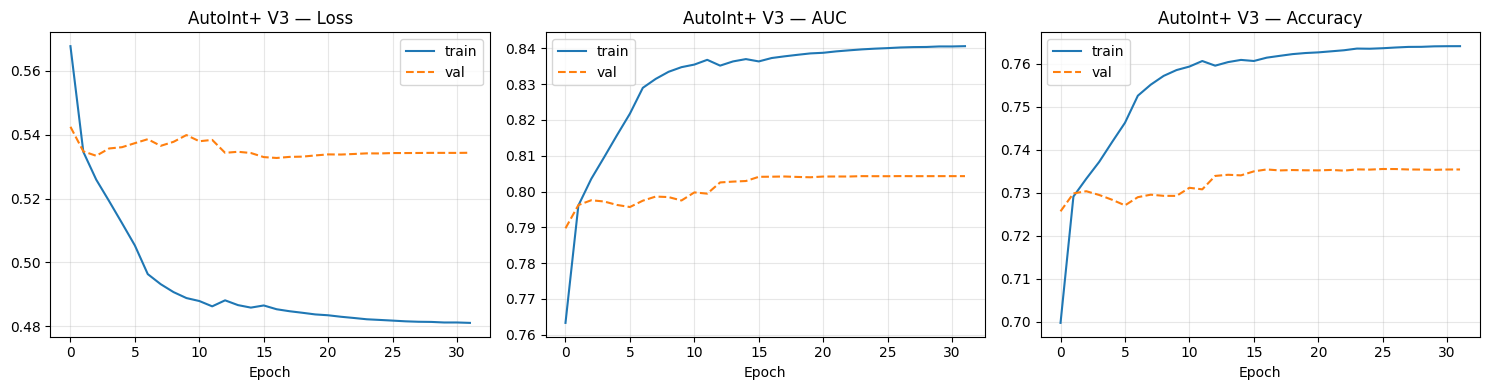

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title in zip(
    axes,
    ['loss', 'auc', 'acc'],
    ['Loss', 'AUC', 'Accuracy']
):
    ax.plot(history.history[metric],     label='train')
    ax.plot(history.history[f'val_{metric}'], label='val', linestyle='--')
    ax.set_title(f'AutoInt+ V3 — {title}')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_curve_v3.png'), dpi=120)
plt.show()

---
## 7. 테스트셋 평가

In [26]:
test_results = model.evaluate(test_ds, verbose=1)
print('\n[Test Set]')
for name, val in zip(model.metrics_names, test_results):
    print(f'  {name}: {val:.4f}')

98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - acc: 0.7376 - auc: 0.8064 - loss: 0.5310

[Test Set]
  loss: 0.5310
  compile_metrics: 0.8064


---
## 8. 가중치 저장 & 로드

In [27]:
# ── 최종 가중치 저장: .weights.h5 형식 ───────────────────────────
model.save_weights(WEIGHT_PATH)
print(f'가중치 저장 완료: {WEIGHT_PATH}')

가중치 저장 완료: ./model/autoIntMLP_V3_weights.weights.h5


In [28]:
# ── 가중치 로드 (재사용 시) ──────────────────────────────────────
# 동일한 field_dims로 모델 재생성 후 로드
model_loaded = AutoIntMLPModel_V3(
    field_dims      = field_dims,
    embedding_size  = EMBED_SIZE,
    att_layer_num   = ATT_LAYER_NUM,
    att_head_num    = ATT_HEAD_NUM,
    att_res         = ATT_RES,
    dnn_hidden_units= DNN_HIDDEN,
    dnn_dropout     = DNN_DROPOUT,
)
# 가중치 초기화를 위해 더미 forward pass
_ = model_loaded(np.zeros((1, len(field_dims)), dtype=np.int64))

# 로드
model_loaded.load_weights(WEIGHT_PATH)
print(f'가중치 로드 완료: {WEIGHT_PATH}')

가중치 로드 완료: ./model/autoIntMLP_V3_weights.weights.h5


---
## 9. 추론 — 특정 유저 Top-10 추천

In [29]:
def recommend_for_user(
    user_raw_id: int,
    df_movies: pd.DataFrame,
    encoders: dict,
    model: AutoIntMLPModel_V3,
    top: int = 10
):
    """
    Parameters
    ----------
    user_raw_id : 원본 user_id (label encoding 전 값)
    df_movies   : narrative_keyword 포함 영화 DataFrame
    encoders    : fit된 LabelEncoder dict
    model       : 학습된 AutoIntMLPModel_V3
    top         : 반환 추천 수
    """
    # 유저 인덱스 변환
    try:
        user_idx = int(encoders['user_id'].transform([str(user_raw_id)])[0])
    except ValueError:
        print(f'user_id {user_raw_id} 가 학습 데이터에 없습니다.')
        return []

    # 전체 영화 후보 조합 생성
    rows = []
    for _, row in df_movies.iterrows():
        try:
            m_idx  = int(encoders['movie_id'].transform([str(row['movie_id'])])[0])
            # genre: df_movies에 genre 컬럼 없으면 0으로 처리
            g_idx  = int(encoders['genre'].transform([str(row.get('genre', '0'))])[0]) \
                     if 'genre' in row else 0
            nk     = str(row.get('narrative_keyword', '기타'))
            nk_idx = int(encoders['narrative_keyword'].transform([nk])[0])
            rows.append([user_idx, m_idx, g_idx, nk_idx])
        except Exception:
            continue

    pred_df = pd.DataFrame(rows, columns=['user_idx','movie_idx','genre_idx','narrative_keyword_idx'])
    
    # predict_model 호출 (autointmlp_v3.py에 정의)
    top_results = predict_model(model, pred_df, top=top)
    
    # movie_idx → 원본 movie_id 역변환
    idx2movie = {v: k for k, v in
                 zip(encoders['movie_id'].classes_,
                     range(len(encoders['movie_id'].classes_)))}
    
    result_movies = []
    for movie_idx, score in top_results:
        raw_id = idx2movie.get(movie_idx, 'Unknown')
        title  = df_movies.loc[df_movies['movie_id'] == int(raw_id), 'movie_title'].values
        title  = title[0] if len(title) > 0 else 'Unknown'
        result_movies.append({'movie_id': raw_id, 'title': title, 'score': round(score, 4)})
    
    return pd.DataFrame(result_movies)


# ── 예시 실행 ─────────────────────────────────────────────────────
df_movies = pd.read_csv(NARRATIVE_PATH)   # movie_id, movie_title, narrative_keyword

# 존재하는 user_id 하나를 가져와서 테스트
sample_user = df_ratings['user_id'].iloc[0]
result = recommend_for_user(sample_user, df_movies, encoders, model, top=10)
print(f'User {sample_user} 추천 결과:')
display(result)

User 1 추천 결과:


,movie_id,title,score
0,2503,"Apple, The (Sib) (1998)",0.9911
1,2673,Eternity and a Day (Mia eoniotita ke mia mera ...,0.9906
2,3601,"Castaway Cowboy, The (1974)",0.9897
3,2833,Lucie Aubrac (1997),0.9863
4,3353,"Closer You Get, The (2000)",0.9861
5,985,Small Wonders (1996),0.9856
6,2493,"Harmonists, The (1997)",0.9853
7,3306,"Circus, The (1928)",0.9851
8,3222,Carmen (1984),0.9833
9,3236,Zachariah (1971),0.9789


---
## 10. 체크포인트(Best) 가중치 로드 후 재평가

In [30]:
# EarlyStopping의 restore_best_weights=True 로 인해 model 자체는 이미 best 상태이지만,
# 명시적으로 best checkpoint를 로드하는 방법도 남겨둠

model_best = AutoIntMLPModel_V3(
    field_dims      = field_dims,
    embedding_size  = EMBED_SIZE,
    att_layer_num   = ATT_LAYER_NUM,
    att_head_num    = ATT_HEAD_NUM,
    dnn_hidden_units= DNN_HIDDEN,
    dnn_dropout     = DNN_DROPOUT,
)
_ = model_best(np.zeros((1, len(field_dims)), dtype=np.int64))
model_best.load_weights(BEST_WEIGHT)

model_best.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc'), 'binary_accuracy']
)
best_results = model_best.evaluate(test_ds, verbose=1)
print('\n[Best Checkpoint — Test Set]')
for name, val in zip(model_best.metrics_names, best_results):
    print(f'  {name}: {val:.4f}')

98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - auc: 0.8064 - binary_accuracy: 0.7376 - loss: 0.5306

[Best Checkpoint — Test Set]
  loss: 0.5306
  compile_metrics: 0.8064
